In [20]:
import numpy as np
import matplotlib.pyplot as plt

In [11]:
import tensorflow as tf
print(tf.__version__)

2.3.0


In [21]:
import tensorflow.keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
%matplotlib inline

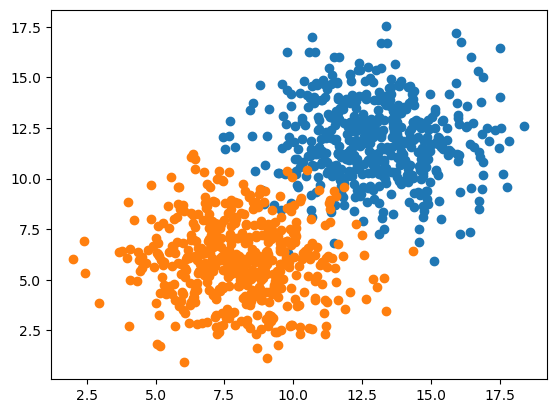

In [27]:
n_pts = 500
np.random.seed(0)
Xa = np.array([np.random.normal(13, 2, n_pts),
               np.random.normal(12, 2, n_pts)]).T       #(500,2)
Xb = np.array([np.random.normal(8, 2, n_pts),
               np.random.normal(6, 2, n_pts)]).T        #(500,2)
 
X = np.vstack((Xa, Xb))                                 #(1000,2)
y = np.matrix(np.append(np.zeros(n_pts), np.ones(n_pts))).T     
"""First 500 points → label 0 (Class A) Next 500 points → label 1 (Class B)
T → column vector shape (1000, 1). This is a binary classification problem."""
plt.scatter(X[:n_pts,0], X[:n_pts,1])       #Plot Class A points (first 500 rows)
plt.scatter(X[n_pts:,0], X[n_pts:,1])       #Plot Class B points (remaining 500 rows)

In [ ]:
model = Sequential()
model.add(Dense(units=1, input_shape=(2,), activation='sigmoid'))       #
adam=Adam(lr = 0.1 )                                                    #Learning rate
model.compile(optimizer = adam, loss='binary_crossentropy', metrics=['accuracy'])
h=model.fit(x=X, y=y, verbose=1, batch_size=50,epochs=500, shuffle='true')
#verbose=1 will display the progress bar of info relating to performance of our model in each epoch.
#Less epoch = Underfit, More epoch = Overfit (Epoch = 10)
"""shuffle='true' will suffle row in data and for each i++ trains only a subset of them. This ensures that the
subset of training data changes every single i++ and if our algo stuck in local min will bounce back to global min"""

Epoch 1/500
20/20 [==============================] - 0s 738us/step - loss: 5.7217 - accuracy: 0.4930
Epoch 2/500
20/20 [==============================] - 0s 635us/step - loss: 1.4810 - accuracy: 0.4600
Epoch 3/500
20/20 [==============================] - 0s 1ms/step - loss: 0.7268 - accuracy: 0.5490
Epoch 4/500
20/20 [==============================] - 0s 974us/step - loss: 0.5769 - accuracy: 0.6720
Epoch 5/500
20/20 [==============================] - 0s 860us/step - loss: 0.4922 - accuracy: 0.7870
Epoch 6/500
20/20 [==============================] - 0s 629us/step - loss: 0.4396 - accuracy: 0.8390
Epoch 7/500
20/20 [==============================] - 0s 564us/step - loss: 0.4011 - accuracy: 0.8700
Epoch 8/500
20/20 [==============================] - 0s 434us/step - loss: 0.3614 - accuracy: 0.9060
Epoch 9/500
20/20 [==============================] - 0s 670us/step - loss: 0.3213 - accuracy: 0.9270
Epoch 10/500
20/20 [==============================] - 0s 521us/step - loss: 0.2952 - accuracy

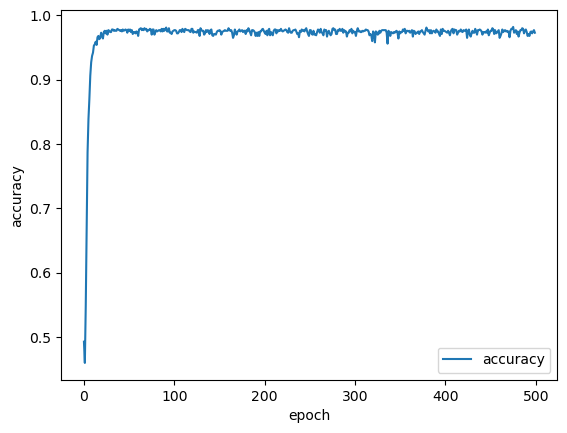

In [29]:
plt.plot(h.history['accuracy']) 
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['accuracy'])

Text(0.5, 0, 'epoch')

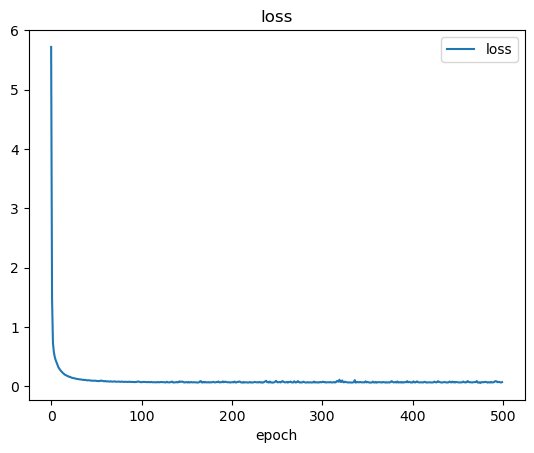

In [16]:
plt.plot(h.history['loss'])
plt.legend(['loss'])
plt.title('loss')
plt.xlabel('epoch')

In [ ]:
def plot_decision_boundary(X, y, model):
    x_span = np.linspace(min(X[:,0]) - 1, max(X[:,0]) + 1)
    """Gives left most hori value and right most hori value  
    50 equally sapced values between min hori value to max hori value
    -+1 will provide the tolerance, provide more visually appealing and spacious grid"""
    y_span = np.linspace(min(X[:,1]) - 1, max(X[:,1]) + 1)
    #Same but for verti coord

    xx, yy = np.meshgrid(x_span, y_span)
    """Takes x-span and returns a 2 dim 50x50 matrix 
    The newly added rows are the repeated copies of origianl row x_span
    Same for y_span"""
    xx_, yy_ = xx.ravel(), yy.ravel()
    grid = np.c_[xx_, yy_]              #Conactenates flatten arrays col wise
    pred_func = model.predict(grid)     
    z = pred_func.reshape(xx.shape)     
    #Prediction with (50,50)arr of predictions which matches the coordinates of every single point in our grid
    plt.contourf(xx, yy, z)
    #x values,y values, magnitude of probability at each corresponding coord
    """Plots the distinct contour zones, each zones represents an increased threshold of prob"""

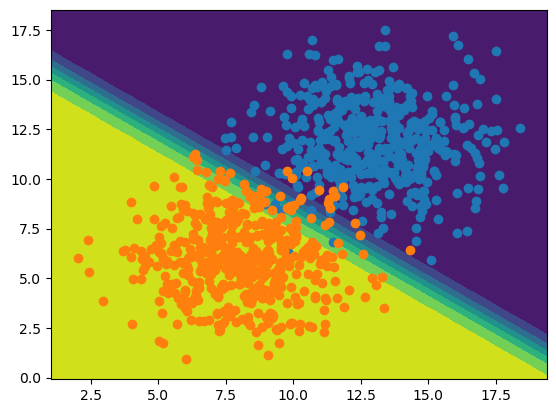

In [18]:
plot_decision_boundary(X, y, model)
plt.scatter(X[:n_pts,0], X[:n_pts,1])
plt.scatter(X[n_pts:,0], X[n_pts:,1])

Plotting for single value

prediction is:  [[0.9999756]]


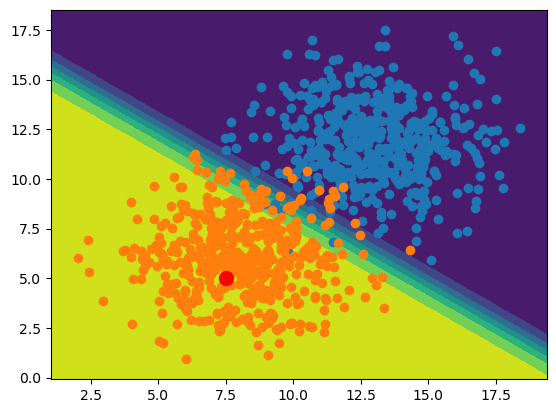

In [ ]:
plot_decision_boundary(X, y, model)
plt.scatter(X[:n_pts,0], X[:n_pts,1])
plt.scatter(X[n_pts:,0], X[n_pts:,1])

x = 7.5
y = 5
point = np.array([[x, y]])
prediction = model.predict(point)
plt.plot([x], [y], marker='o', markersize=10, color="red")
print("prediction is: ",prediction)